# Export simulation encapsulins for FIB-SEM comparison

Reads the **final frame** of a ReaDDy `trajectory.h5`, extracts the **encapsulin (Qt + QtC)**
positions with their **ground-truth cluster IDs** (from ReaDDy's topology graph — no DBSCAN),
unwraps each cluster across the periodic box, and writes the data in the **same schema the
FIB-SEM segmentation produces**, so it drops straight into the existing analysis pipeline.

Outputs (into `OUT_DIR`):
- `encapsulin_centroids_simulation.csv` — one row per encapsulin
  (`label, z/y/x_nm, z/y/x_vox, radius_nm, volume_nm3, cluster, is_clustered`)
- `structural_information_and_metadata_simulation.json` — run info + parameters

Ferritin (Ft) is dropped (sub-resolution in FIB-SEM) but is used internally for the PBC
unwrap. Volumes are analytical (4/3·π·r³); `radius_nm` is stored per row so a later notebook
can compute an **exact** mass integral ⟨M(R)⟩ without approximation.

Requires the `readdy` environment and the `qtft` package (put `fibsem_export.py` in `qtft/`).

## Settings

In [1]:
import os

# --- point this at your run directory ---
# Single runs land in   Simulation_Files_Single_Runs/<param_string>/
# ensemble replicas in  Simulation_Files_Ensembles/<param_string>/replica_000/
SIM_DIR     = "Simulation_Files_Single_Runs/1200Qt_2400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_reflective_loops"  # absolute path to the run directory (or a parent dir for auto-detect)

# Leave both None to auto-detect (fibsem_export.find_run_files). It handles plain runs
# (trajectory.h5), phased agglomeration<->deagglomeration runs (trajectory_combined.h5,
# else the last phase_NNN/trajectory.h5), and locates the config: <param_string>_config.json
# for a single run, or ensemble_config.json for an ensemble replica.
TRAJECTORY  = None                       # e.g. "trajectory_combined.h5" to force one
CONFIG_JSON = None                       # e.g. an absolute path to a config JSON

# --- output ---
OUT_DIR     = "FIBSEM_Comparison_Export" # where the CSV + JSON are written
VOXEL_NM    = 4.0                        # match the FIB-SEM voxel size
FILE_TAG    = "_simulation"              # distinguishes these files from the EM data

## Run

Loads the config, extracts the encapsulins, writes the files, prints a summary, and shows a
quick 2D scatter coloured by cluster — the fast visual check that the PBC unwrap worked (no
cluster should appear split across the box).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qtft.config import SimulationConfig
from qtft import fibsem_export

traj_path, config_path = fibsem_export.find_run_files(SIM_DIR, TRAJECTORY, CONFIG_JSON)
print(f"trajectory  : {traj_path}")
print(f"config      : {config_path}\n")
config = SimulationConfig.load_json(config_path)

df, info = fibsem_export.export(traj_path, config, OUT_DIR, voxel_nm=VOXEL_NM, file_tag=FILE_TAG)

print(f"final frame : step {info['final_step']:.0f}  ({info['final_time_us']:.4g} us)")
print(f"encapsulins : {info['n_encapsulins']}  "
      f"(clustered {info['n_clustered']}, free {info['n_free']})")
print(f"clusters    : {info['n_clusters']}  "
      f"(multi-particle {info['n_multi_particle_clusters']}, largest {info['largest_cluster']})")
print(f"box (nm)    : {info['box_size_nm']}   Qt radius (nm): {info['qt_radius_nm']}")
print(f"size dist   : {info['cluster_size_distribution']}   (cluster_size: n_clusters)")
print(f"written to  : {OUT_DIR}/")

# every encapsulin in the system must appear exactly once
assert info["n_encapsulins"] == config.n_qt, (
    f"exported {info['n_encapsulins']} encapsulins but the system has {config.n_qt}")
df.head()

trajectory  : Simulation_Files_Single_Runs/1200Qt_2400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_reflective_loops/1200Qt_2400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_reflective_loops.h5
config      : Simulation_Files_Single_Runs/1200Qt_2400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_reflective_loops/1200Qt_2400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_reflective_loops_config.json

✓ Configuration loaded from Simulation_Files_Single_Runs/1200Qt_2400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_reflective_loops/1200Qt_2400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_reflective_loops_config.json
fibsem_export: particles observable absent; streaming to final frame
fibsem_export: final frame paired with topology record 750 (step 750000)
fibsem_export: wrote FIBSEM_Comparison_Export/encapsulin_centroids_simulation.csv
fibsem_export: wrote FIBSEM_Comparison_Export/structural_information_and_metadata_simulation.json
final frame : step 750000  (7.5e+05 us)
encapsulins : 1200  (cl

,label,z_nm,y_nm,x_nm,z_vox,y_vox,x_vox,radius_nm,volume_nm3,cluster,is_clustered
0,1,834.469809,156.588356,94.548705,208.617452,39.147089,23.637176,25.0,65449.84695,1,False
1,2,519.612997,130.430610,562.621854,129.903249,32.607653,140.655463,25.0,65449.84695,2,True
2,3,546.141086,166.190824,587.584267,136.535272,41.547706,146.896067,25.0,65449.84695,2,True
3,4,548.646760,119.678769,610.651540,137.161690,29.919692,152.662885,25.0,65449.84695,2,True
4,5,458.538199,174.783111,602.326999,114.634550,43.695778,150.581750,25.0,65449.84695,2,True


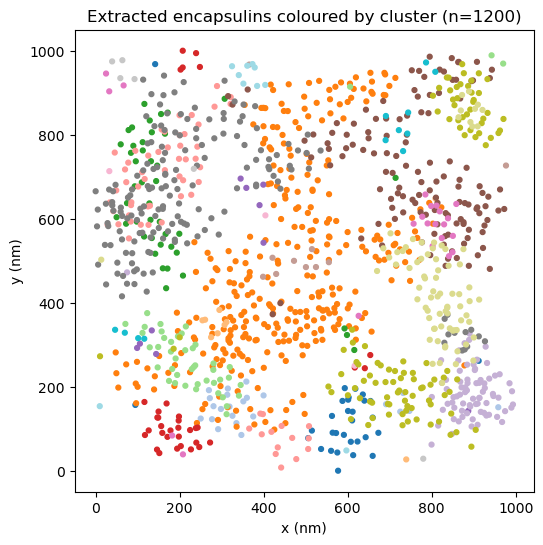

In [3]:
# sanity visual: 2D projection coloured by cluster (unwrapped, shifted coordinates)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["x_nm"], df["y_nm"], c=df["cluster"], cmap="tab20", s=12)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
ax.set_title(f"Extracted encapsulins coloured by cluster (n={len(df)})")
plt.show()

### Next steps

`encapsulin_centroids_simulation.csv` already carries ground-truth `cluster` IDs, so it can go
straight into the structural-analysis notebook (skipping the DBSCAN clustering step used for
FIB-SEM). The napari validation and the simulation-vs-FIB-SEM plotting notebooks come next.